# Dataset Disagreement Figures

Generates PDF confusion-matrix heatmaps comparing original WildGuardMix labels (`Dataset Harm`) against human annotator labels (`Annotator Harm`), used in the appendix of the paper.

**Outputs** (`report/latex/img/`):
- `annotator_dataset_disagreement.pdf` — all prompts
- `annotator_dataset_disagreement_adversarial.pdf` — split by adversarial status

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from datasets import concatenate_datasets, load_dataset
from sklearn.metrics import confusion_matrix

OUTPUT_DIR = Path("../../report/latex/img")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
ds = concatenate_datasets([
    load_dataset("Jazhyc/wildguard-annotated-intents", split="train"),
    load_dataset("Jazhyc/wildguard-annotated-intents", split="validation"),
    load_dataset("Jazhyc/wildguard-annotated-intents", split="test"),
])
df = ds.to_pandas()

# Map 4-category annotator labels to binary
harm_map = {
    "Completely Harmful": "harmful",
    "Uncertain Harmful": "harmful",
    "Uncertain Safe": "safe",
    "Completely Safe": "safe",
}
df["annotator_binary"] = df["Annotator Harm"].map(harm_map)
df["dataset_binary"] = df["Dataset Harm"].str.lower()

df = df.dropna(subset=["annotator_binary", "dataset_binary"])
print(f"Total prompts: {len(df)}")
df[["Dataset Harm", "dataset_binary", "Annotator Harm", "annotator_binary"]].head()

Total prompts: 1724


,Dataset Harm,dataset_binary,Annotator Harm,annotator_binary
0,Safe,safe,Uncertain Harmful,harmful
1,Safe,safe,Uncertain Harmful,harmful
2,Safe,safe,Uncertain Harmful,harmful
3,Safe,safe,Completely Safe,safe
4,Safe,safe,Completely Safe,safe


In [3]:
LABELS = ["harmful", "safe"]
DISPLAY_LABELS = ["Harmful", "Safe"]

def plot_disagreement_heatmap(
    subset: pd.DataFrame,
    ax: plt.Axes,
    title: str,
) -> None:
    """Plot a percentage-of-total confusion matrix on the given axes."""
    cm = confusion_matrix(
        subset["dataset_binary"],
        subset["annotator_binary"],
        labels=LABELS,
    )
    cm_pct = cm / cm.sum() * 100

    sns.heatmap(
        cm_pct,
        annot=True,
        fmt=".2f",
        xticklabels=DISPLAY_LABELS,
        yticklabels=DISPLAY_LABELS,
        cmap="Blues",
        vmin=cm_pct.min(),
        vmax=cm_pct.max(),
        annot_kws={"fontsize": 14, "fontweight": "bold"},
        cbar_kws={"label": "Percentage (%) of Total"},
        ax=ax,
    )
    ax.set_xlabel("Annotator Label", fontsize=12)
    ax.set_ylabel("Original Dataset Label", fontsize=12)
    ax.set_title(f"{title}\n(n={len(subset):,} prompts)", fontsize=13)

Saved ../../report/latex/img/annotator_dataset_disagreement.pdf


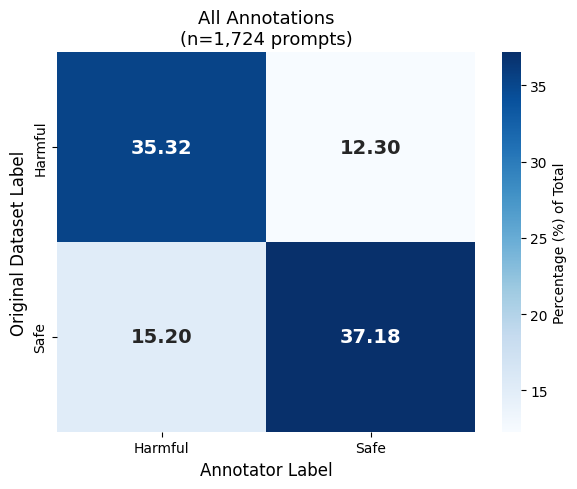

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_disagreement_heatmap(df, ax, "All Annotations")
fig.tight_layout()

out = OUTPUT_DIR / "annotator_dataset_disagreement.pdf"
fig.savefig(out, bbox_inches="tight")
print(f"Saved {out}")
plt.show()

Saved ../../report/latex/img/annotator_dataset_disagreement_adversarial.pdf


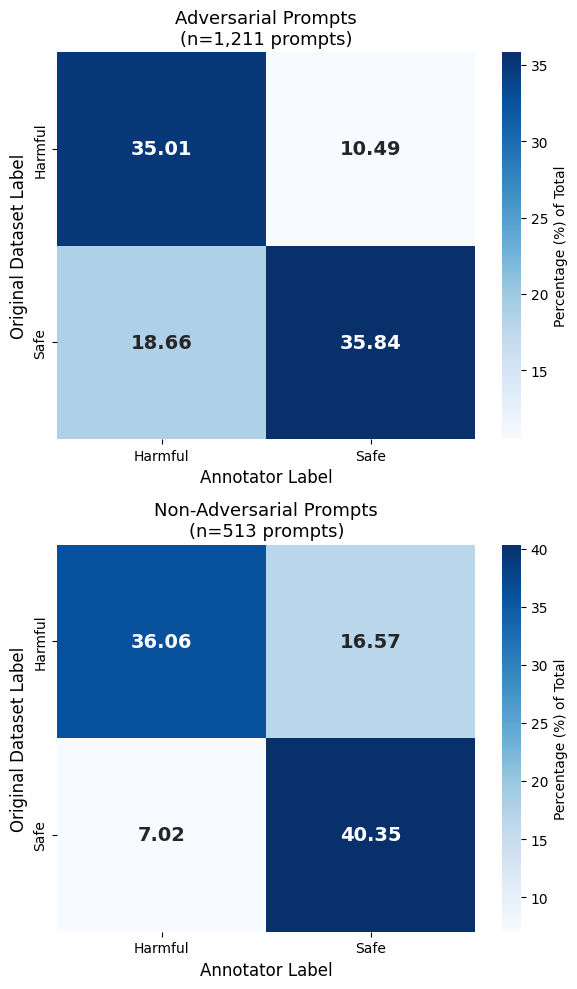

In [5]:
adversarial = df[df["Adversarial"] == True]
non_adversarial = df[df["Adversarial"] == False]

fig, axes = plt.subplots(2, 1, figsize=(6, 10))
plot_disagreement_heatmap(adversarial, axes[0], "Adversarial Prompts")
plot_disagreement_heatmap(non_adversarial, axes[1], "Non-Adversarial Prompts")
fig.tight_layout()

out = OUTPUT_DIR / "annotator_dataset_disagreement_adversarial.pdf"
fig.savefig(out, bbox_inches="tight")
print(f"Saved {out}")
plt.show()